Dataset audit

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/raw/dataset-1.csv')
df.info()
display(df.head())

print("=================================================================================")
print(df.describe())
print("=================================================================================")
print(df.columns)
print("=================================null================================================")
print(df.isnull().sum())
print("=================================nan================================================")
print(df.isna().sum())
print("===================================dup============================================")
print(df.duplicated().sum())
print("===================================shape============================================")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  
Index(['Order_ID', 'Distanc

identify the target

the target is the delivery time in minutes its the most important feature to predict , we can rely on it for prediction of the delivery time , its already integer and have a good name that indicate that the values are by minute .

In [2]:
target  = df['Delivery_Time_min']
print(target.head(3))
print(target.dtype)

data_dictionary = pd.DataFrame([
      {
          "column": "Order_ID",
          "meaning": "Unique identifier for each delivery order",
          "dtype": str(df["Order_ID"].dtype),
          "unit": "None",
          "modeling_decision": "Exclude; identifier with no predictive meaning"
      },
      {
          "column": "Distance_km",
          "meaning": "Distance between the restaurant and customer",
          "dtype": str(df["Distance_km"].dtype),
          "unit": "Kilometres",
          "modeling_decision": "Use as predictor"
      },
      {
          "column": "Weather",
          "meaning": "Weather condition during the delivery",
          "dtype": str(df["Weather"].dtype),
          "unit": "Category",
          "modeling_decision": "Use as predictor"
      },
      {
          "column": "Traffic_Level",
          "meaning": "Traffic conditions during the delivery",
          "dtype": str(df["Traffic_Level"].dtype),
          "unit": "Category",
          "modeling_decision": "Use as predictor"
      },
      {
          "column": "Time_of_Day",
          "meaning": "Period of the day when delivery occurs",
          "dtype": str(df["Time_of_Day"].dtype),
          "unit": "Category",
          "modeling_decision": "Use as predictor"
      },
      {
          "column": "Vehicle_Type",
          "meaning": "Vehicle used by the courier",
          "dtype": str(df["Vehicle_Type"].dtype),
          "unit": "Category",
          "modeling_decision": "Use conditionally"
      },
      {
          "column": "Preparation_Time_min",
          "meaning": "Time required to prepare the order",
          "dtype": str(df["Preparation_Time_min"].dtype),
          "unit": "Minutes",
          "modeling_decision": "Potential leakage; verify before use"
      },
      {
          "column": "Courier_Experience_yrs",
          "meaning": "Courier's delivery experience",
          "dtype": str(df["Courier_Experience_yrs"].dtype),
          "unit": "Years",
          "modeling_decision": "Use conditionally"
      },
      {
          "column": "Delivery_Time_min",
          "meaning": "Total observed delivery time",
          "dtype": str(df["Delivery_Time_min"].dtype),
          "unit": "Minutes",
          "modeling_decision": "Target; never include as a predictor"
      }
  ])

display(data_dictionary)

0    43
1    84
2    59
Name: Delivery_Time_min, dtype: int64
int64


,column,meaning,dtype,unit,modeling_decision
0,Order_ID,Unique identifier for each delivery order,int64,None,Exclude; identifier with no predictive meaning
1,Distance_km,Distance between the restaurant and customer,float64,Kilometres,Use as predictor
2,Weather,Weather condition during the delivery,str,Category,Use as predictor
3,Traffic_Level,Traffic conditions during the delivery,str,Category,Use as predictor
4,Time_of_Day,Period of the day when delivery occurs,str,Category,Use as predictor
5,Vehicle_Type,Vehicle used by the courier,str,Category,Use conditionally
6,Preparation_Time_min,Time required to prepare the order,int64,Minutes,Potential leakage; verify before use
7,Courier_Experience_yrs,Courier's delivery experience,float64,Years,Use conditionally
8,Delivery_Time_min,Total observed delivery time,int64,Minutes,Target; never include as a predictor


cleaning data setup

In [3]:
from src.data import (
load_raw_data,
clean_delivery_data,
create_train_test_split,
)
raw_df = load_raw_data()


cleaned_df = clean_delivery_data(raw_df)

print("raw shape:", raw_df.shape)
print("cleaned shape:", cleaned_df.shape)
display(cleaned_df.head())
print(cleaned_df.isna().sum())
print("exact duplicates", raw_df.duplicated().sum())
print("repeated order ids:", raw_df["Order_ID"].duplicated().sum())



Order_ID min: 1 max: 1000
Distance_km min: 0.59 max: 19.99
Preparation_Time_min min: 5 max: 29
Courier_Experience_yrs min: 0.0 max: 9.0
Delivery_Time_min min: 8 max: 153
raw shape: (1000, 9)
cleaned shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
exact duplicates 0
repeated order ids: 0


Visualisation

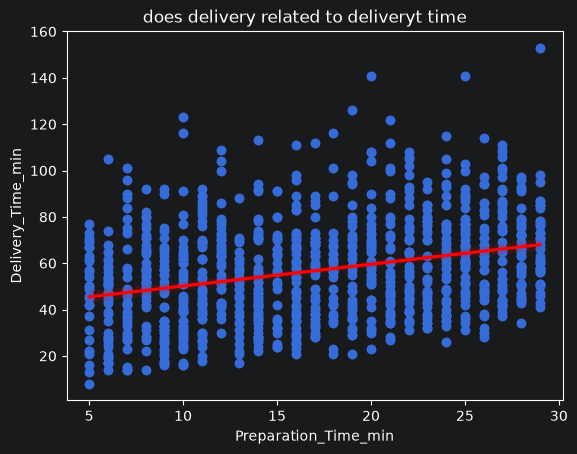

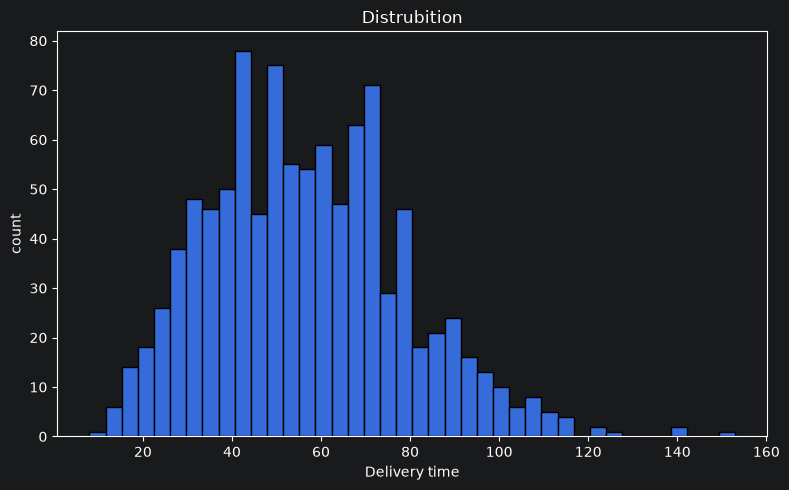

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(cleaned_df["Preparation_Time_min"], cleaned_df["Delivery_Time_min"])
sns.regplot(
    data=cleaned_df,
    x = "Preparation_Time_min",
    y = "Delivery_Time_min",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("does delivery related to deliveryt time    ")
plt.show()
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
      cleaned_df["Delivery_Time_min"],
      bins=40,
      edgecolor="black"
  )

ax.set_title("Distrubition")
ax.set_xlabel("Delivery time")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_397/2606572712.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


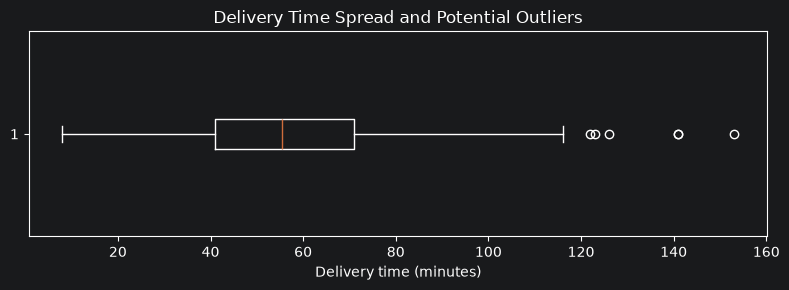

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.boxplot(
  cleaned_df["Delivery_Time_min"].dropna(),
  vert=False
)

ax.set_title("Delivery Time Spread and Potential Outliers")
ax.set_xlabel("Delivery time (minutes)")

plt.tight_layout()
plt.show()




analyse descriptive

In [12]:
xtrain , xtest, ytrain, ytest = create_train_test_split(cleaned_df)
train_eda = xtrain.copy()
train_eda["Delivery_Time_min"] = ytrain
print(train_eda.columns)
print(train_eda.describe())
print(train_eda["Weather"].value_counts(), train_eda["Weather"].value_counts(normalize=True).mul(100))
print(train_eda["Traffic_Level"].value_counts(), train_eda["Traffic_Level"].value_counts(normalize=True).mul(100))
print(train_eda["Vehicle_Type"].value_counts(),train_eda["Vehicle_Type"].value_counts(normalize=True).mul(100))


Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Courier_Experience_yrs', 'Delivery_Time_min'],
      dtype='str')
       Distance_km  Courier_Experience_yrs  Delivery_Time_min
count    800.00000              776.000000         800.000000
mean      10.10055                4.606959          57.053750
std        5.72590                2.946649          22.278774
min        0.59000                0.000000           8.000000
25%        5.13000                2.000000          41.000000
50%       10.22000                5.000000          56.000000
75%       14.94250                7.000000          71.000000
max       19.99000                9.000000         153.000000
Weather
Clear    375
Rainy    164
Foggy     82
Windy     80
Snowy     77
Name: count, dtype: int64[pyarrow] Weather
Clear    48.200514
Rainy    21.079692
Foggy    10.539846
Windy    10.282776
Snowy     9.897172
Name: proportion, dtype: double[pyarrow]
Traffic_Level
Medium    311
Low    

plot the target distribution and report its median , spread and long tail

In [18]:
ax.hist(
      ytrain,
      bins=40,
      edgecolor="black"
  )

ax.set_title("Distrubition")
ax.set_xlabel("Delivery time")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>